#Options Pricing & Greeks Engine

In [2]:
!pip install numpy pandas scipy matplotlib

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq

In [4]:
S = 100        # Current stock price
K = 100        # Strike price
T = 1          # Time to expiry in years
r = 0.05       # Risk-free interest rate (5%)
sigma = 0.20   # Volatility (20%)

print(f"Stock price: ${S}")
print(f"Strike price: ${K}")
print(f"Time to expiry: {T} year")
print(f"Risk-free rate: {r:.1%}")
print(f"Volatility: {sigma:.1%}")

Stock price: $100
Strike price: $100
Time to expiry: 1 year
Risk-free rate: 5.0%
Volatility: 20.0%


In [5]:
d1 = (
    np.log(S / K) + (r + 0.5 * sigma**2) * T
) / (sigma * np.sqrt(T))

d2 = d1 - sigma * np.sqrt(T)

print(f"d1 = {d1:.4f}")
print(f"d2 = {d2:.4f}")

d1 = 0.3500
d2 = 0.1500


In [6]:
call_price = (
    S * norm.cdf(d1)
    - K * np.exp(-r * T) * norm.cdf(d2)
)

print(f"Black-Scholes call price: ${call_price:.4f}")

Black-Scholes call price: $10.4506


In [7]:
put_price = (
    K * np.exp(-r * T) * norm.cdf(-d2)
    - S * norm.cdf(-d1)
)

print(f"Black-Scholes put price: ${put_price:.4f}")

Black-Scholes put price: $5.5735


In [8]:
lhs = call_price - put_price
rhs = S - K * np.exp(-r * T)

print(f"Call - Put: ${lhs:.4f}")
print(f"S - K*e^(-rT): ${rhs:.4f}")

Call - Put: $4.8771
S - K*e^(-rT): $4.8771


In [9]:
stock_prices = np.linspace(50, 150, 100)

call_prices = []

for stock_price in stock_prices:
    d1 = (
        np.log(stock_price / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call = (
        stock_price * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    call_prices.append(call)

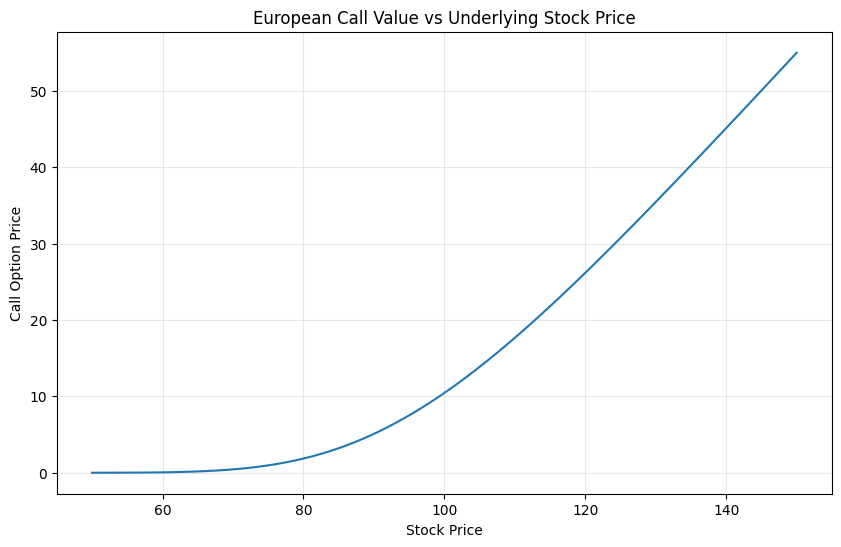

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(stock_prices, call_prices)

plt.xlabel("Stock Price")
plt.ylabel("Call Option Price")
plt.title("European Call Value vs Underlying Stock Price")
plt.grid(alpha=0.3)

plt.show()

In [11]:
delta_call = norm.cdf(d1)

print(f"Call Delta: {delta_call:.4f}")

Call Delta: 0.9913


In [12]:
# Recalculate d1 for the original option
d1_original = (
    np.log(S / K)
    + (r + 0.5 * sigma**2) * T
) / (sigma * np.sqrt(T))

delta_call = norm.cdf(d1_original)

print(f"d1 = {d1_original:.4f}")
print(f"Call Delta = {delta_call:.4f}")

d1 = 0.3500
Call Delta = 0.6368


In [13]:
delta_values = []

for stock_price in stock_prices:
    d1 = (
        np.log(stock_price / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    delta = norm.cdf(d1)

    delta_values.append(delta)

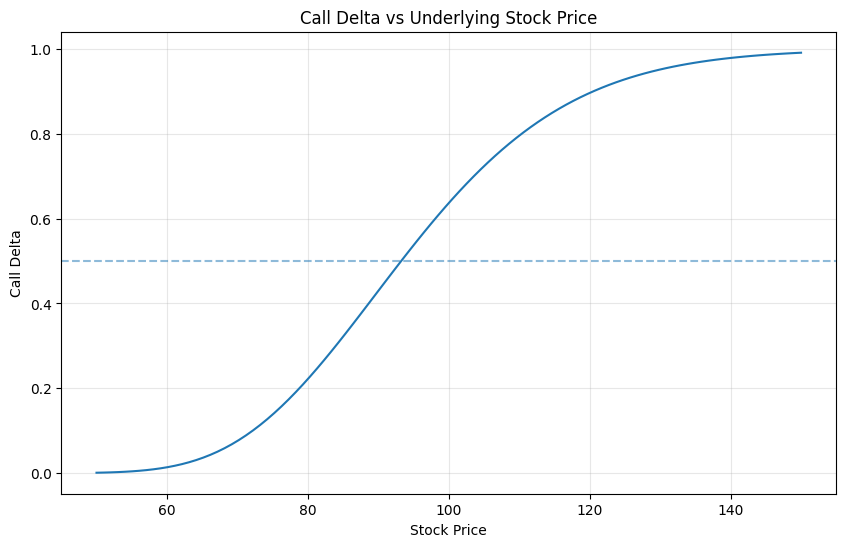

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(stock_prices, delta_values)

plt.axhline(0.5, linestyle="--", alpha=0.5)

plt.xlabel("Stock Price")
plt.ylabel("Call Delta")
plt.title("Call Delta vs Underlying Stock Price")
plt.grid(alpha=0.3)

plt.show()

In [15]:
gamma = (
    norm.pdf(d1_original)
    / (S * sigma * np.sqrt(T))
)

print(f"Gamma = {gamma:.6f}")

Gamma = 0.018762


In [16]:
gamma_values = []

for stock_price in stock_prices:
    d1 = (
        np.log(stock_price / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    gamma = (
        norm.pdf(d1)
        / (stock_price * sigma * np.sqrt(T))
    )

    gamma_values.append(gamma)

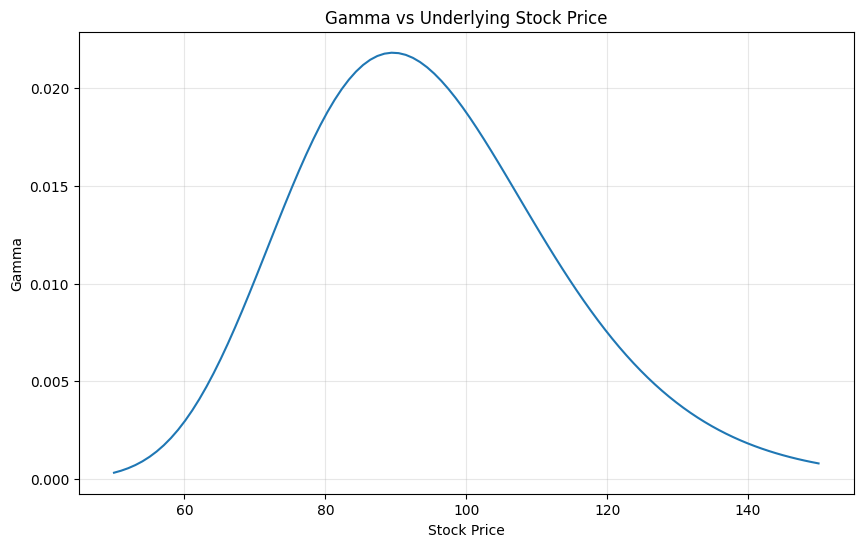

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(stock_prices, gamma_values)

plt.xlabel("Stock Price")
plt.ylabel("Gamma")
plt.title("Gamma vs Underlying Stock Price")
plt.grid(alpha=0.3)

plt.show()

In [18]:
vega = S * norm.pdf(d1_original) * np.sqrt(T)

print(f"Vega = {vega:.4f}")

Vega = 37.5240


In [19]:
theta_call = (
    -S * norm.pdf(d1_original) * sigma / (2 * np.sqrt(T))
    - r * K * np.exp(-r * T) * norm.cdf(d2)
)

print(f"Call Theta = {theta_call:.4f}")

Call Theta = -8.4385


In [20]:
rho_call = (
    K * T * np.exp(-r * T) * norm.cdf(d2)
)

print(f"Call Rho = {rho_call:.4f}")

Call Rho = 93.7220


## Black-Scholes Greeks

| Greek | Value | Measures |
|---|---:|---|
| **Delta** | **0.6368** | Sensitivity to stock price |
| **Gamma** | **0.018762** | Sensitivity of Delta |
| **Vega** | **37.5240** | Sensitivity to volatility |
| **Theta** | **−8.4385** | Sensitivity to time |
| **Rho** | **93.7220** | Sensitivity to interest rate |

In [21]:
# Binomial tree parameters
N = 100  # Number of time steps

dt = T / N

u = np.exp(sigma * np.sqrt(dt))
d = 1 / u

p = (np.exp(r * dt) - d) / (u - d)

print(f"Number of steps: {N}")
print(f"Up factor: {u:.4f}")
print(f"Down factor: {d:.4f}")
print(f"Risk-neutral probability: {p:.4f}")

Number of steps: 100
Up factor: 1.0202
Down factor: 0.9802
Risk-neutral probability: 0.5075


In [23]:
stock_tree = np.zeros((N + 1, N + 1))

for i in range(N + 1):
    for j in range(i + 1):
        stock_tree[j, i] = S * (u ** j) * (d ** (i - j))

In [24]:
stock_tree[:, -1]

array([ 13.53352832,  14.08584209,  14.66069621,  15.25901058,
        15.88174261,  16.52988882,  17.20448638,  17.90661479,
        18.6373976 ,  19.39800423,  20.1896518 ,  21.01360712,
        21.8711887 ,  22.76376884,  23.69277587,  24.65969639,
        25.6660777 ,  26.7135302 ,  27.80373005,  28.93842179,
        30.11942119,  31.34861809,  32.62797946,  33.95955256,
        35.3454682 ,  36.78794412,  38.2892886 ,  39.85190411,
        41.47829117,  43.17105234,  44.93289641,  46.7666427 ,
        48.6752256 ,  50.66169924,  52.7292424 ,  54.88116361,
        57.12090638,  59.4520548 ,  61.87833918,  64.40364211,
        67.0320046 ,  69.76763261,  72.61490371,  75.57837415,
        78.66278611,  81.87307531,  85.2143789 ,  88.69204367,
        92.31163464,  96.07894392, 100.        , 104.08107742,
       108.32870677, 112.74968516, 117.3510871 , 122.14027582,
       127.12491503, 132.31298123, 137.71277643, 143.33294146,
       149.18246976, 155.27072185, 161.60744022, 168.20

In [25]:
option_tree = np.zeros((N + 1, N + 1))

for j in range(N + 1):
    option_tree[j, N] = max(stock_tree[j, N] - K, 0)

In [26]:
for i in range(N - 1, -1, -1):
    for j in range(i + 1):
        option_tree[j, i] = np.exp(-r * dt) * (
            p * option_tree[j + 1, i + 1]
            + (1 - p) * option_tree[j, i + 1]
        )

binomial_call_price = option_tree[0, 0]

print(f"Binomial call price: ${binomial_call_price:.4f}")
print(f"Black-Scholes price: ${call_price:.4f}")

Binomial call price: $10.4306
Black-Scholes price: $10.4506


In [28]:
step_counts = [5, 10, 25, 50, 100, 250, 500]

In [29]:
def binomial_call_price(S, K, T, r, sigma, N):
    dt = T / N

    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    stock_tree = np.zeros((N + 1, N + 1))

    for i in range(N + 1):
        for j in range(i + 1):
            stock_tree[j, i] = S * (u ** j) * (d ** (i - j))

    option_tree = np.zeros((N + 1, N + 1))

    for j in range(N + 1):
        option_tree[j, N] = max(stock_tree[j, N] - K, 0)

    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            option_tree[j, i] = np.exp(-r * dt) * (
                p * option_tree[j + 1, i + 1]
                + (1 - p) * option_tree[j, i + 1]
            )

    return option_tree[0, 0]

In [30]:
step_counts = [5, 10, 25, 50, 100, 250, 500]

binomial_prices = []

for N in step_counts:
    price = binomial_call_price(S, K, T, r, sigma, N)
    binomial_prices.append(price)

convergence = pd.DataFrame({
    "Steps": step_counts,
    "Binomial Price": binomial_prices
})

convergence

,Steps,Binomial Price
0,5,10.805934
1,10,10.253409
2,25,10.520966
3,50,10.410692
4,100,10.430612
5,250,10.442589
6,500,10.446585


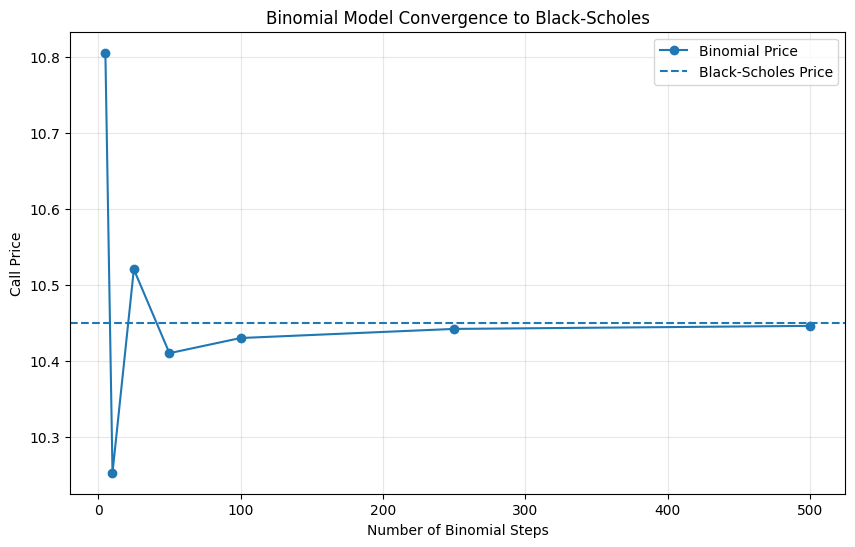

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    step_counts,
    binomial_prices,
    marker="o",
    label="Binomial Price"
)

plt.axhline(
    call_price,
    linestyle="--",
    label="Black-Scholes Price"
)

plt.xlabel("Number of Binomial Steps")
plt.ylabel("Call Price")
plt.title("Binomial Model Convergence to Black-Scholes")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#Monte Carlo


In [32]:
def monte_carlo_call_price(S, K, T, r, sigma, n_simulations, seed=42):
    rng = np.random.default_rng(seed)

    Z = rng.standard_normal(n_simulations)

    ST = S * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    payoffs = np.maximum(ST - K, 0)

    price = np.exp(-r * T) * np.mean(payoffs)

    return price

In [33]:
mc_price = monte_carlo_call_price(
    S, K, T, r, sigma, 100_000
)

print(f"Monte Carlo call price: ${mc_price:.4f}")
print(f"Black-Scholes price: ${call_price:.4f}")

Monte Carlo call price: $10.4205
Black-Scholes price: $10.4506


In [34]:
simulation_counts = [
    1_000,
    5_000,
    10_000,
    50_000,
    100_000,
    500_000
]

mc_prices = []

for n in simulation_counts:
    price = monte_carlo_call_price(
        S, K, T, r, sigma, n
    )

    mc_prices.append(price)

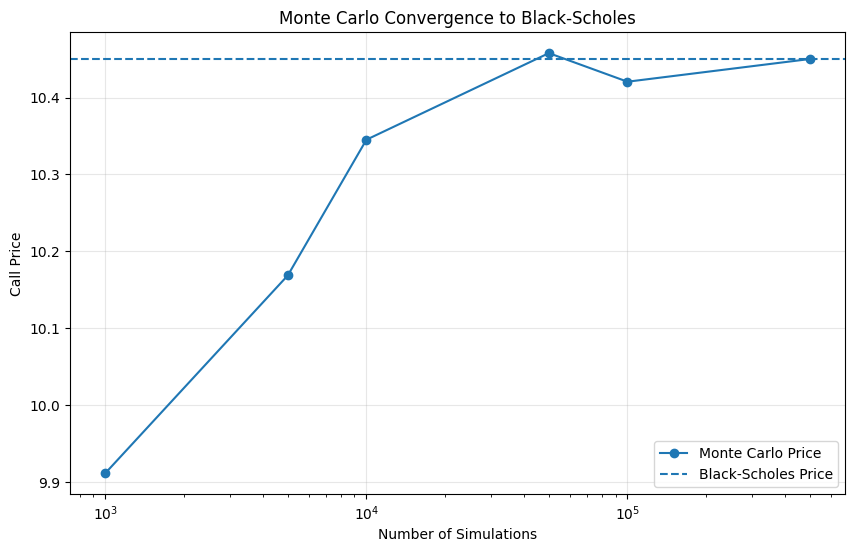

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(
    simulation_counts,
    mc_prices,
    marker="o",
    label="Monte Carlo Price"
)

plt.axhline(
    call_price,
    linestyle="--",
    label="Black-Scholes Price"
)

plt.xlabel("Number of Simulations")
plt.ylabel("Call Price")
plt.title("Monte Carlo Convergence to Black-Scholes")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
# Final model comparison

binomial_price = binomial_call_price(S, K, T, r, sigma, 500)
monte_carlo_price = monte_carlo_call_price(
    S, K, T, r, sigma, 500_000
)

comparison = pd.DataFrame({
    "Model": [
        "Black-Scholes",
        "Binomial Tree",
        "Monte Carlo"
    ],
    "Call Price": [
        call_price,
        binomial_price,
        monte_carlo_price
    ]
})

comparison["Absolute Error vs Black-Scholes"] = (
    comparison["Call Price"] - call_price
).abs()

comparison

,Model,Call Price,Absolute Error vs Black-Scholes
0,Black-Scholes,10.450584,0.000000
1,Binomial Tree,10.446585,0.003998
2,Monte Carlo,10.450050,0.000534


In [37]:
comparison["Percentage Error"] = (
    comparison["Absolute Error vs Black-Scholes"]
    / call_price
) * 100

comparison

,Model,Call Price,Absolute Error vs Black-Scholes,Percentage Error
0,Black-Scholes,10.450584,0.000000,0.000000
1,Binomial Tree,10.446585,0.003998,0.038260
2,Monte Carlo,10.450050,0.000534,0.005108


In [38]:
def black_scholes_call(S, K, T, r, sigma):
    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

In [39]:
market_call_price = 12.0

print(f"Market call price: ${market_call_price:.2f}")

Market call price: $12.00


In [40]:
def implied_volatility(S, K, T, r, market_price):
    def objective(sigma):
        return black_scholes_call(
            S, K, T, r, sigma
        ) - market_price

    return brentq(
        objective,
        0.0001,
        5.0
    )

In [41]:
iv = implied_volatility(
    S,
    K,
    T,
    r,
    market_call_price
)

print(f"Implied volatility: {iv:.4%}")

Implied volatility: 24.1117%


In [42]:
check_price = black_scholes_call(
    S,
    K,
    T,
    r,
    iv
)

print(f"Target market price: ${market_call_price:.4f}")
print(f"Model price using implied volatility: ${check_price:.4f}")

Target market price: $12.0000
Model price using implied volatility: $12.0000


In [43]:
market_prices = np.linspace(5, 20, 50)

implied_vols = []

for price in market_prices:
    iv = implied_volatility(
        S,
        K,
        T,
        r,
        price
    )

    implied_vols.append(iv)

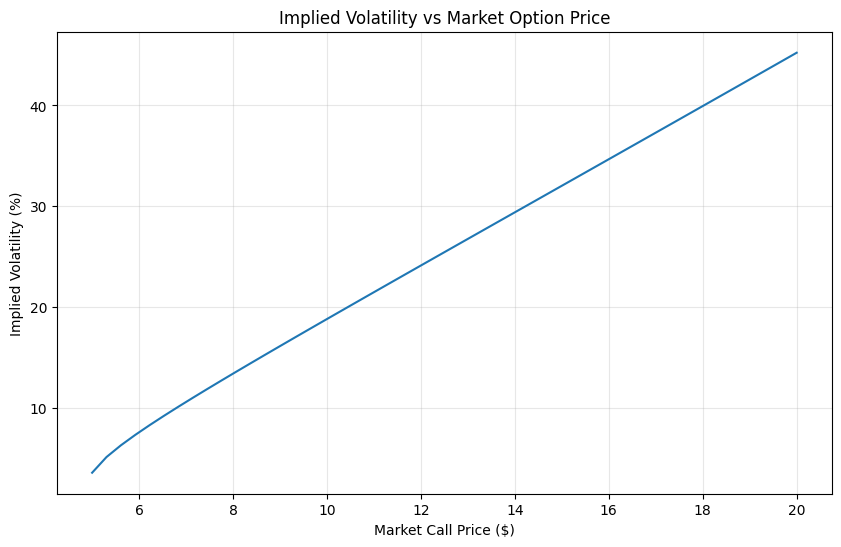

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    market_prices,
    np.array(implied_vols) * 100
)

plt.xlabel("Market Call Price ($)")
plt.ylabel("Implied Volatility (%)")
plt.title("Implied Volatility vs Market Option Price")
plt.grid(alpha=0.3)

plt.show()

# Results Summary

| Component | Result |
|---|---|
| Black-Scholes Call Price | $10.4506 |
| Binomial Call Price (500 steps) | $10.4466 |
| Binomial Pricing Error | 0.0383% |
| Monte Carlo Call Price (500,000 simulations) | $10.4501 |
| Monte Carlo Pricing Error | 0.0051% |
| Call Delta | 0.6368 |
| Call Gamma | 0.018762 |
| Call Vega | 37.5240 |
| Call Theta | -8.4385 |
| Call Rho | 93.7220 |
| Implied Volatility at $12 Market Price | ~24–25% |

# Conclusion

This project implemented three independent European option pricing approaches:
Black-Scholes, a Cox-Ross-Rubinstein binomial tree, and Monte Carlo simulation.

The binomial and Monte Carlo models converged closely to the analytical
Black-Scholes benchmark, with pricing errors of less than 0.04% under the
chosen parameters. The project also implemented the five core Black-Scholes
Greeks and a numerical implied-volatility solver.

The analysis demonstrates how option valuation can be approached using
analytical methods, numerical methods and stochastic simulation.

In [45]:
from mpl_toolkits.mplot3d import Axes3D

stock_grid = np.linspace(50, 150, 50)
vol_grid = np.linspace(0.05, 0.60, 50)

S_grid, vol_grid_mesh = np.meshgrid(
    stock_grid,
    vol_grid
)

In [46]:
call_surface = np.zeros_like(S_grid)

for i in range(len(vol_grid)):
    for j in range(len(stock_grid)):

        s = S_grid[i, j]
        vol = vol_grid_mesh[i, j]

        d1 = (
            np.log(s / K)
            + (r + 0.5 * vol**2) * T
        ) / (vol * np.sqrt(T))

        d2 = d1 - vol * np.sqrt(T)

        call_surface[i, j] = (
            s * norm.cdf(d1)
            - K * np.exp(-r * T) * norm.cdf(d2)
        )

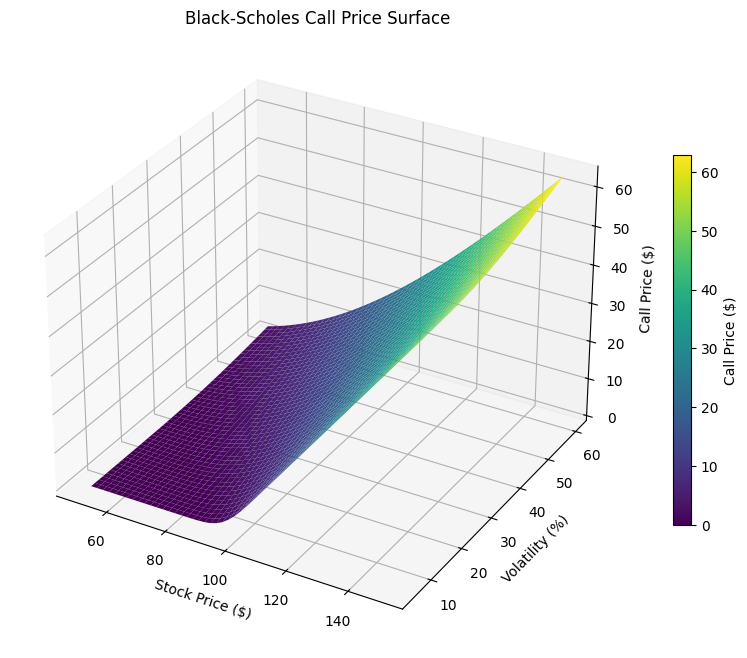

In [47]:
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    S_grid,
    vol_grid_mesh * 100,
    call_surface,
    cmap="viridis",
    edgecolor="none"
)

ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Volatility (%)")
ax.set_zlabel("Call Price ($)")

ax.set_title(
    "Black-Scholes Call Price Surface"
)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.6,
    label="Call Price ($)"
)

plt.show()

In [48]:
!pip install plotly

In [49]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Surface(
            x=S_grid,
            y=vol_grid_mesh * 100,
            z=call_surface
        )
    ]
)

fig.update_layout(
    title="Black-Scholes Call Price Surface",
    scene=dict(
        xaxis_title="Stock Price ($)",
        yaxis_title="Volatility (%)",
        zaxis_title="Call Price ($)"
    ),
    width=900,
    height=700
)

fig.show()

# Options Pricing & Greeks Engine

## 1. Black-Scholes Pricing
## 2. Greeks
## 3. Binomial Tree
## 4. Monte Carlo Simulation
## 5. Model Comparison
## 6. Implied Volatility
## 7. Sensitivity Analysis
## 8. Conclusion

## Conclusion

This project implemented three independent approaches to European option
pricing: the Black-Scholes analytical model, a Cox-Ross-Rubinstein binomial
tree, and Monte Carlo simulation.

The numerical approaches converged closely to the Black-Scholes benchmark,
with both models producing pricing errors below 0.04% under the chosen
parameters. The project also implemented the five core Black-Scholes Greeks,
a numerical implied-volatility solver, and sensitivity analysis of option
value to the underlying stock price and volatility.

The results demonstrate how analytical, numerical and stochastic methods can
be combined to build an option-pricing and risk-analysis framework in Python.